# Netflix Content Analysis - EDA

### Business Problem
Netflix has a large and diverse content library, but it is
important to understand how this content is distributed across
different types, genres, countries, ratings, and time periods.

### Business Objective
To analyze Netflix's movies and TV shows to understand its
content strategy and identify key content patterns and trends.


# Import libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Load Datasets

In [2]:
df = pd.read_csv("Netflix-Movies-TVshow-Sample.csv")
df.head()    #first 5 row


,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.tail()      #last 5 rows

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,20-Nov-19,2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,1-Jul-19,2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,1-Nov-19,2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,11-Jan-20,2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2-Mar-19,2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


# Data Understanding

In [4]:
df.columns  

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='str')

In [5]:
df.shape  #identifying the size of dataset

(8807, 12)

In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [7]:
df.dtypes              #checking which type of data types a column have

show_id           str
type              str
title             str
director          str
cast              str
country           str
date_added        str
release_year    int64
rating            str
duration          str
listed_in         str
description       str
dtype: object

In [8]:
df.describe()           #checking descriptive statistic

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [9]:
df.isnull().sum()         #checking missing values 

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [10]:
df["type"].unique()          #checking uniques values

<StringArray>
['Movie', 'TV Show']
Length: 2, dtype: str

In [11]:
df["rating"].unique()

<StringArray>
[   'PG-13',    'TV-MA',       'PG',    'TV-14',    'TV-PG',     'TV-Y',
    'TV-Y7',        'R',     'TV-G',        'G',    'NC-17',   '74 min',
   '84 min',   '66 min',       'NR',        nan, 'TV-Y7-FV',       'UR']
Length: 18, dtype: str

In [12]:
df.loc[df['rating'].str.contains('min|Season', case=False, na=False),['title', 'rating', 'duration']]   # identifying which rows of rating contains duration values

,title,rating,duration
5541,Louis C.K. 2017,74 min,NaN
5794,Louis C.K.: Hilarious,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,66 min,NaN


In [13]:
df["duration"].unique()

<StringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',
 ...
    '43 min',   '200 min',   '196 min',   '167 min',   '178 min',   '228 min',
    '18 min',   '205 min',   '201 min',   '191 min']
Length: 221, dtype: str

In [14]:
df["country"].value_counts()

country
United States                                    2818
India                                             972
United Kingdom                                    419
Japan                                             245
South Korea                                       199
                                                 ... 
Russia, Spain                                       1
Croatia, Slovenia, Serbia, Montenegro               1
Japan, Canada                                       1
United States, France, South Korea, Indonesia       1
United Arab Emirates, Jordan                        1
Name: count, Length: 748, dtype: int64

In [15]:
df["listed_in"].value_counts()

listed_in
Dramas, International Movies                        362
Documentaries                                       359
Stand-Up Comedy                                     334
Comedies, Dramas, International Movies              274
Dramas, Independent Movies, International Movies    252
                                                   ... 
Comedies, Cult Movies, LGBTQ Movies                   1
Action & Adventure, Comedies, Horror Movies           1
Classic & Cult TV, Crime TV Shows, TV Dramas          1
Action & Adventure, Documentaries, Sports Movies      1
Cult Movies, Dramas, Thrillers                        1
Name: count, Length: 514, dtype: int64

## Data Understanding — Conclusion

The Netflix dataset contains 8,807 records and 12 columns covering
information about movies and TV shows, including content type, title,
director, cast, country, date added, release year, rating, duration,
genre, and description.

The initial assessment identified missing values in several columns,
with the highest number of missing values found in the `director`
column. The `date_added` column is stored as a string and will need to
be converted to datetime format for time-based analysis.

A data inconsistency was also identified in the `rating` column, where
some records contain duration-related values. This issue will need to
be investigated and corrected during the data-cleaning stage.

The `country` and `listed_in` columns contain multiple values within
some records and will require appropriate transformation for
category-level analysis.



Therefore, further data cleaning and validation are required 

# Data Cleaning

In [16]:
df. duplicated().sum()       #checking any duplicates in dataset

np.int64(0)

### Duplicate Check

No duplicate records were found in the dataset. Therefore, no rows
were removed based on duplication.

In [17]:
#handling data missing
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [18]:
pd.crosstab(df['type'], df['director'].isna())       #Check missing director values by content type

director,False,True
type,,
Movie,5943,188
TV Show,230,2446


In [19]:
df['director'] = df['director'].fillna('Unknown')

The `director` column has 2,634 missing values. Most of these missing
values are from TV Shows, while only a small number are from Movies.
We will not delete these rows because it would result in losing a
large amount of useful data. Since the missing director names cannot
be known from the dataset, we replaced the missing values with
`Unknown`.

In [20]:
# Check missing cast values by content type
pd.crosstab(df['type'], df['cast'].isna())

cast,False,True
type,,
Movie,5656,475
TV Show,2326,350


In [21]:
df['cast'] = df['cast'].fillna('Unknown')

The `cast` column has 825 missing values. Missing values are present
in both Movies and TV Shows.
We will not delete these rows because they contain other useful
information. Since the missing cast names cannot be identified from
the dataset, we will replace the missing values with `Unknown`.

In [22]:
# Check missing country values by content type
pd.crosstab(df['type'], df['country'].isna())

country,False,True
type,,
Movie,5691,440
TV Show,2285,391


In [23]:
df['country'] = df['country'].fillna('Unknown')

The `country` column has 831 missing values. Missing values are
present in both Movies and TV Shows.
We will not delete these rows because they contain other useful
information. Since the missing country cannot be identified from the
dataset, we will replace the missing values with `Unknown`.

In [24]:
df[df['date_added'].isna()][['title', 'type', 'release_year', 'date_added']]

,title,type,release_year,date_added
6066,A Young Doctor's Notebook and Other Stories,TV Show,2013,NaN
6174,Anthony Bourdain: Parts Unknown,TV Show,2018,NaN
6795,Frasier,TV Show,2003,NaN
6806,Friends,TV Show,2003,NaN
6901,Gunslinger Girl,TV Show,2008,NaN
7196,Kikoriki,TV Show,2010,NaN
7254,La Familia P. Luche,TV Show,2012,NaN
7406,Maron,TV Show,2016,NaN
7847,Red vs. Blue,TV Show,2015,NaN
8182,The Adventures of Figaro Pho,TV Show,2015,NaN


In [25]:
# Remove records with missing date_added
df = df.dropna(subset=['date_added'])

In [26]:
df['date_added'].isnull().sum()

np.int64(0)

In [27]:
#verifying dataset size now
df.shape

(8797, 12)

There were 10 records with missing values in the `date_added` column.
Since `date_added` is important for our time-based analysis and these
records represent only a very small portion of the dataset, we removed
these 10 records. Now the Netflix dataset contains 8,797 records and 12 columns

In [28]:
# Identify duration values incorrectly placed in the rating column
df[df['rating'].str.contains('min|Season', case=False, na=False)][
    ['title', 'type', 'rating', 'duration']
]

,title,type,rating,duration
5541,Louis C.K. 2017,Movie,74 min,NaN
5794,Louis C.K.: Hilarious,Movie,84 min,NaN
5813,Louis C.K.: Live at the Comedy Store,Movie,66 min,NaN


In [29]:
# Move duration values from rating to the duration column
mask = df['rating'].str.contains('min|Season', case=False, na=False)

df.loc[mask, 'duration'] = df.loc[mask, 'rating']
df.loc[mask, 'rating'] = np.nan

In [30]:
# Verify the corrected rating and duration values
df.loc[mask, ['title', 'rating', 'duration']]


,title,rating,duration
5541,Louis C.K. 2017,NaN,74 min
5794,Louis C.K.: Hilarious,NaN,84 min
5813,Louis C.K.: Live at the Comedy Store,NaN,66 min


In [31]:
# Check remaining missing values in the rating column
df['rating'].isnull().sum()

np.int64(7)

In [32]:
# Replace missing rating values with Unknown
df['rating'] = df['rating'].fillna('Unknown')

After correcting the duration values that were incorrectly placed in
the rating column, 7 rating values remained missing.
Since the actual ratings cannot be identified from the dataset, the
missing values were replaced with `Unknown`.

In [33]:
# Check remaining missing values in the duration column
df['duration'].isnull().sum()

np.int64(0)

In [34]:
# Display unique duration values
df['duration'].unique()

<StringArray>
[   '90 min', '2 Seasons',  '1 Season',    '91 min',   '125 min', '9 Seasons',
   '104 min',   '127 min', '4 Seasons',    '67 min',
 ...
    '43 min',   '200 min',   '196 min',   '167 min',   '178 min',   '228 min',
    '18 min',   '205 min',   '201 min',   '191 min']
Length: 220, dtype: str

In [35]:
#final checking missing value
df.isnull().sum()


show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

In [36]:
# Convert date_added from string to datetime using the known date format
df['date_added'] = pd.to_datetime(df['date_added'],format='%d-%b-%y',errors='coerce')

In [37]:
# Check the data type of date_added
df['date_added'].dtype

dtype('<M8[us]')

In [38]:
# Verify the converted date values
df['date_added'].head()

0   2021-09-25
1   2021-09-24
2   2021-09-24
3   2021-09-24
4   2021-09-24
Name: date_added, dtype: datetime64[us]

The `date_added` column was originally stored as text. It was converted
to datetime format using the correct date format.
This will allow us to perform accurate year- and month-based analysis
during EDA.

## Data Cleaning — Conclusion

The dataset was cleaned by checking and handling missing values,
duplicates, data inconsistencies, and incorrect data types.

Missing values in `director`, `cast`, `country`, and `rating` were
replaced with `Unknown` because their actual values could not be
identified. No duplicate records were found.

Three duration values that were incorrectly stored in the `rating`
column were moved to the `duration` column.

The 10 records with missing `date_added` values were removed because
they represented only a very small portion of the dataset
(approximately 0.11%), and The `date_added` column was then converted from text to datetime format beacuse`date_added` is important for our
time-based analysis.
The cleaned dataset is now ready for exploratory data analysis.

In [74]:
df.to_csv('netflix_cleaned.csv', index=False)

In [39]:
df.shape

(8797, 12)

In [40]:
df.dtypes

show_id                    str
type                       str
title                      str
director                   str
cast                       str
country                    str
date_added      datetime64[us]
release_year             int64
rating                     str
duration                   str
listed_in                  str
description                str
dtype: object

In [41]:
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,Unknown,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,Unknown,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",Unknown,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,Unknown,Unknown,Unknown,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,Unknown,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


## Business Validation 

The cleaned dataset contains all the important columns required to
answer our business questions.

The `type`, `listed_in`, `country`, `rating`, `date_added`,
`release_year`, and `director` columns are available for the planned
analysis.

Some columns such as `country` and `listed_in` contain multiple values
in some records, so they will be transformed before performing
category-level analysis.

The dataset is suitable for the planned business analysis.

# Exploratory Data Analysis (EDA)

The purpose of EDA is to explore the cleaned Netflix dataset, identify
patterns, understand the distribution of variables, and generate
insights that help answer the business questions.
The analysis will include univariate and bivariate analysis, followed
by business-focused analysis and insights.

## Univariate Analysis

### Content Type Distribution
Analyze the frequency of Movies and TV Shows to understand
which type of content is more common on Netflix.

In [42]:
# Check the frequency of each content type
df['type'].value_counts()

type
Movie      6131
TV Show    2666
Name: count, dtype: int64

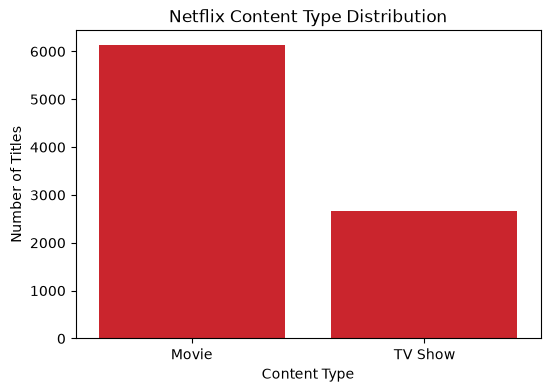

In [62]:
# Visualize the frequency of content types
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='type', color='#E50914')
plt.title('Netflix Content Type Distribution')
plt.xlabel('Content Type')
plt.ylabel('Number of Titles')
plt.savefig('images/content_type.png', dpi=300, bbox_inches='tight')
plt.show()

It shows that Movies make up a larger share of
the Netflix content library compared to TV Shows

### Rating Distribution

Analyze the frequency of content ratings to identify the most
common ratings in the Netflix library.

In [44]:
# Check the frequency of each rating
df['rating'].value_counts()

rating
TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
Unknown        7
TV-Y7-FV       6
NC-17          3
UR             3
Name: count, dtype: int64

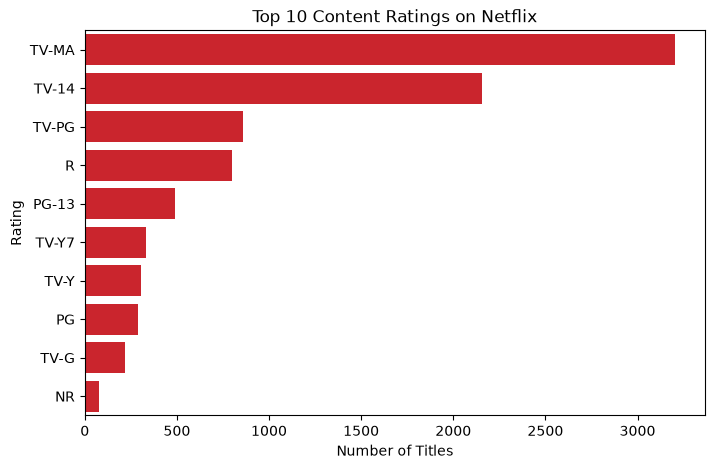

In [63]:
# Visualize the top 10 ratings
rating_counts = df['rating'].value_counts().head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=rating_counts.values, y=rating_counts.index, color='#E50914')

plt.title('Top 10 Content Ratings on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Rating')
plt.savefig('images/rating_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

TV-MA is the most common rating, indicating
that mature-rated content represents a significant portion of the
Netflix library.

### Genre Distribution

The `listed_in` column contains multiple genres in some records.
Therefore, the genres will be separated before calculating their
individual frequencies.

In [46]:
# Split multiple genres and count each genre separately
genre_counts = (df['listed_in'].str.split(', ').explode().value_counts())

genre_counts.head(10)

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1350
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64

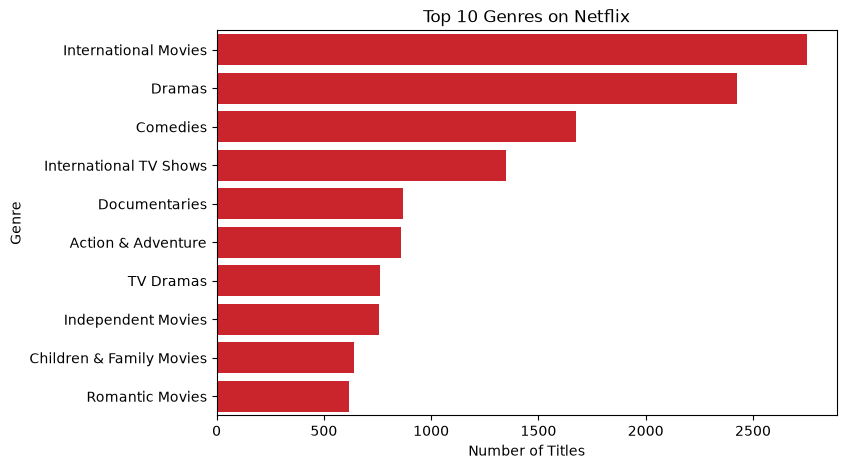

In [64]:
# Visualize the top 10 genres
top_genres = genre_counts.head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_genres.values, y=top_genres.index, color='#E50914')

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.savefig('images/=top_genres.png', dpi=300, bbox_inches='tight')
plt.show()

International Movies is the most common category.


### Country Distribution

The `country` column contains multiple countries in some records.
Therefore, the countries will be separated before calculating their
individual frequencies.

In [48]:
# Split multiple countries and count each country separately
country_counts = (df['country'].str.split(', ').explode().value_counts())
# Remove Unknown from country frequency analysis
country_counts = country_counts.drop('Unknown', errors='ignore')
country_counts.head(10)

country
United States     3683
India             1046
United Kingdom     803
Canada             445
France             393
Japan              317
Spain              232
South Korea        231
Germany            226
Mexico             169
Name: count, dtype: int64

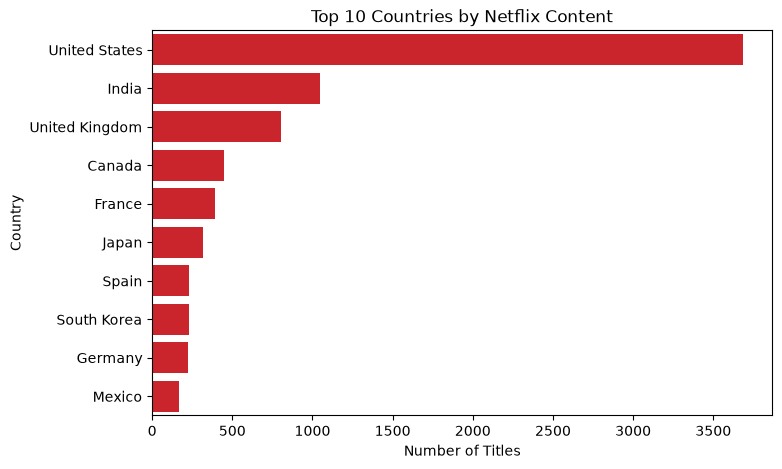

In [65]:
# Visualize the top 10 countries by content count
top_countries = country_counts.head(10)

plt.figure(figsize=(8, 5))
sns.barplot( x=top_countries.values,y=top_countries.index,color='#E50914')
plt.title('Top 10 Countries by Netflix Content')
plt.xlabel('Number of Titles')
plt.ylabel('Country')
plt.savefig('images/=top_countries.png', dpi=300, bbox_inches='tight')
plt.show()

The United States is the leading country in
terms of content contribution.

### Content Added Over Time

Analyze the number of titles added to Netflix each year to
understand how the content library has grown over time.

In [50]:
# Extract the year from date_added
df['added_year'] = df['date_added'].dt.year

# Count titles added in each year
df['added_year'].value_counts().sort_index()

added_year
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64

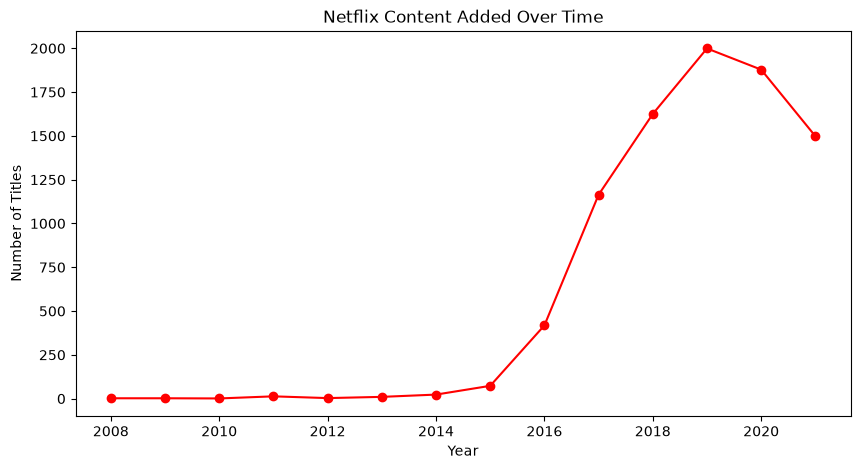

In [66]:
# Calculate the number of titles added each year
yearly_additions = df['added_year'].value_counts().sort_index()

# Visualize yearly content additions
plt.figure(figsize=(10, 5))
plt.plot(yearly_additions.index, yearly_additions.values, marker='o', color='r')

plt.title('Netflix Content Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.savefig('images/=content_added_over_time', dpi=300, bbox_inches='tight')
plt.show()

The number of titles added to Netflix increased significantly after
2015. Content additions grew rapidly from 2016 onward, with 2019
recording the highest number of additions. After 2019, the number of
titles added decreased in 2020 and 2021.

### Release Year Distribution
Analyze the distribution of content by release year to
understand the release periods represented in the Netflix library.

In [52]:
# Count titles by release year
df['release_year'].value_counts().sort_index()

release_year
1925       1
1942       2
1943       3
1944       3
1945       4
        ... 
2017    1032
2018    1146
2019    1030
2020     953
2021     592
Name: count, Length: 74, dtype: int64

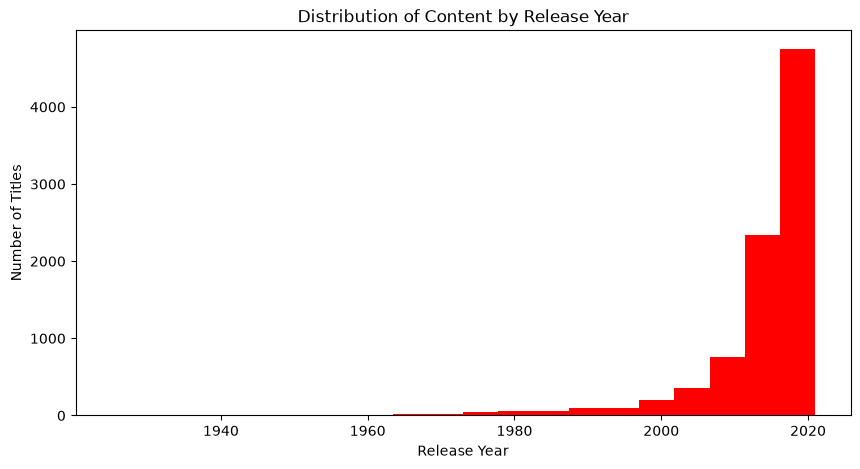

In [67]:
# Visualize the distribution of release years
plt.figure(figsize=(10, 5))

plt.hist(df['release_year'], bins=20 , color="red")

plt.title('Distribution of Content by Release Year')
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.savefig('images/=release_year.png', dpi=300, bbox_inches='tight')
plt.show()


The release year distribution shows that most of the content was
released in recent years. Content released before 1980 is very limited,
while the number of titles increases substantially after 2000.
The highest number of titles was released in 2018, followed by 2017
and 2019. This indicates that the Netflix library is largely
concentrated on relatively recent content, with limited older content.

### Top 10 Directors

We will identify the top 10 directors based on the number of titles
they have contributed to the Netflix library.

In [54]:
# Count titles by director and exclude Unknown values
director_counts = (df[df['director'] != 'Unknown']['director'].value_counts())

director_counts.head(10)

director
Rajiv Chilaka             19
Raúl Campos, Jan Suter    18
Suhas Kadav               16
Marcus Raboy              16
Jay Karas                 14
Cathy Garcia-Molina       13
Youssef Chahine           12
Martin Scorsese           12
Jay Chapman               12
Steven Spielberg          11
Name: count, dtype: int64

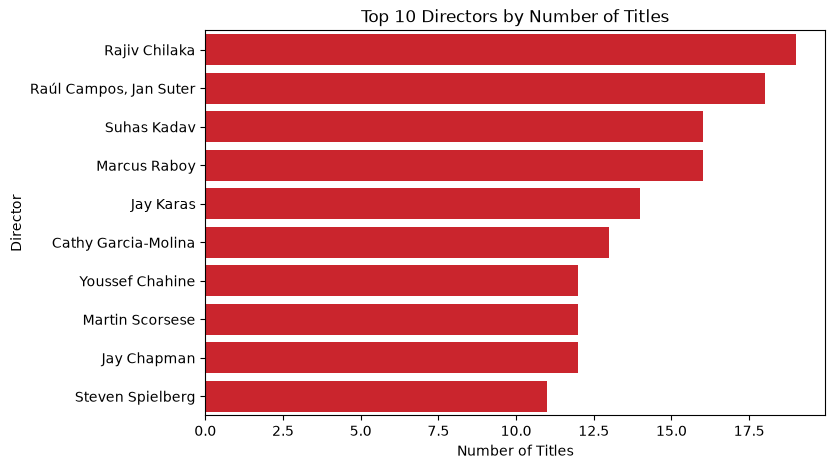

In [68]:
# Visualize the top 10 directors
top_directors = director_counts.head(10)
plt.figure(figsize=(8, 5))
sns.barplot(x=top_directors.values,y=top_directors.index,color='#E50914')
plt.title('Top 10 Directors by Number of Titles')
plt.xlabel('Number of Titles')
plt.ylabel('Director')
plt.savefig('images/=top 10 directors', dpi=300, bbox_inches='tight')
plt.show()

Rajiv Chilaka is the director with the highest number of titles in the
Netflix dataset, making him the top contributor among the directors
analyzed.

# Bivariate Analysis

### Content Type Added Over Time

Compare the number of Movies and TV Shows added to Netflix
across different years to understand how the content mix has changed
over time.

In [56]:
# Count Movies and TV Shows by year
df['year_added'] = df['date_added'].dt.year        # Extract year from date_added

# Count Movies and TV Shows added each year
content_added = df.groupby(['year_added', 'type']).size().unstack(fill_value=0)
content_added

type,Movie,TV Show
year_added,,
2008.0,1,1
2009.0,2,0
2010.0,1,0
2011.0,13,0
2012.0,3,0
2013.0,6,4
2014.0,19,4
2015.0,56,17
2016.0,253,165


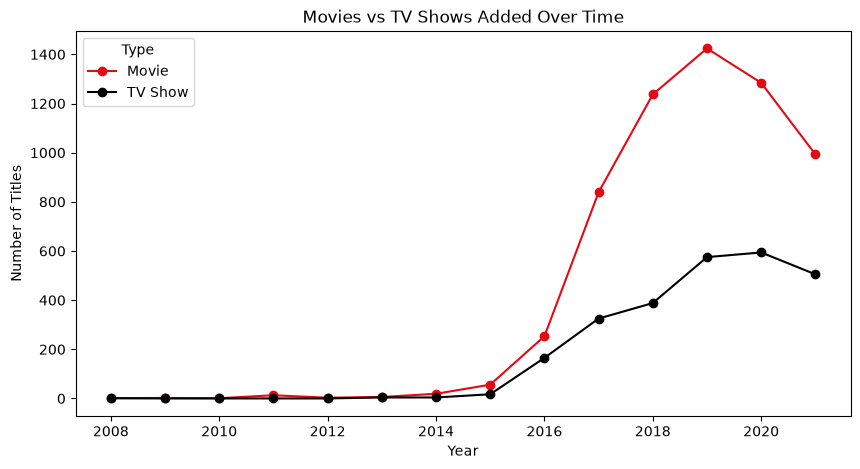

In [73]:
# Plot Movies and TV Shows
content_added.plot(kind='line',figsize=(10, 5),color=['#E50914', '#000000'],marker='o')

plt.title('Movies vs TV Shows Added Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.savefig('images/types added over time.png', dpi=300, bbox_inches='tight')
plt.show()

The analysis shows that more Movies were added to Netflix than TV Shows
in most years.

The highest number of Movies was added in 2019, while the highest number
of TV Shows was added in 2020.

Overall, the addition of both Movies and TV Shows increased after 2015,
but Movies remained higher than TV Shows.

### Rating Distribution by Content Type

We will compare the ratings of Movies and TV Shows to understand how
their rating distributions differ.

In [58]:
# Count ratings for each content type
pd.crosstab(df['rating'], df['type'])

type,Movie,TV Show
rating,,
G,41,0
NC-17,3,0
NR,75,4
PG,287,0
PG-13,490,0
R,797,2
TV-14,1427,730
TV-G,126,94
TV-MA,2062,1143


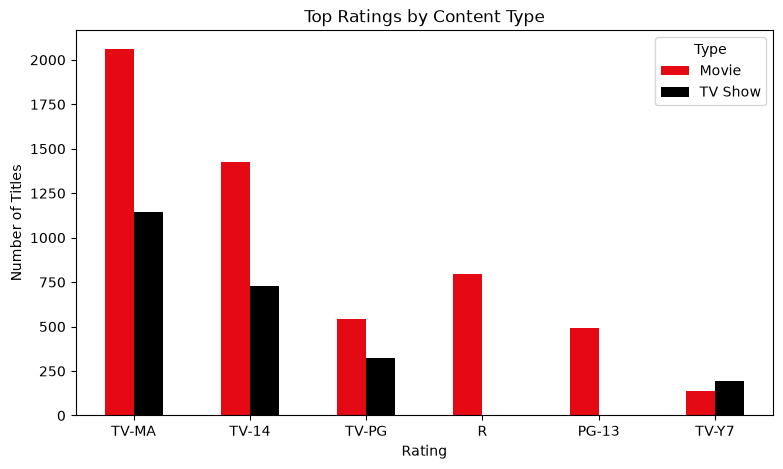

In [69]:
rating_type = pd.crosstab(df['rating'], df['type'])
top_ratings = rating_type.sum(axis=1).sort_values(ascending=False).head(6)
rating_type.loc[top_ratings.index].plot(kind='bar',figsize=(9, 5),color=['#E50914', '#000000'])
plt.title('Top Ratings by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.xticks(rotation=0)
plt.legend(title='Type')
plt.savefig('images/rating_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

The analysis shows that TV-MA is the most common rating for both
Movies and TV Shows.

Movies have a higher number of TV-MA and TV-14 titles, while TV Shows
have more TV-Y and TV-Y7 titles compared to Movies.

### Genre Distribution by Content Type

The `listed_in` column contains multiple genres in some records.
We will separate these genres and compare their distribution across
Movies and TV Shows.

In [60]:
# Keep only the required columns
genre_data = df[['listed_in', 'type']].copy()

# Remove missing genre values
genre_data = genre_data.dropna(subset=['listed_in'])

# Split multiple genres
genre_data['listed_in'] = genre_data['listed_in'].str.split(', ')

# Create separate row for each genre
genre_data = genre_data.explode('listed_in')

# Count genres by content type
genre_type = genre_data.groupby(['listed_in', 'type']).size().unstack(fill_value=0)

# Find the top 5 genres (renamed to avoid clashing with earlier top_genres variable)
top_genres_bytype = genre_data['listed_in'].value_counts().head(5)

top_genres_bytype

listed_in
International Movies      2752
Dramas                    2427
Comedies                  1674
International TV Shows    1350
Documentaries              869
Name: count, dtype: int64

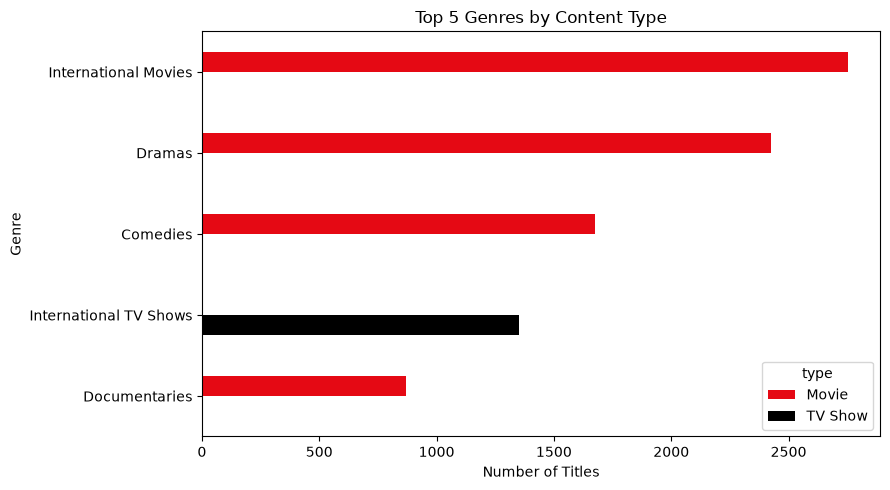

In [70]:
# Plot top 5 genres by content type
genre_type.loc[top_genres_bytype.index].plot(kind='barh',figsize=(9, 5),color=['#E50914', '#000000'])
plt.title('Top 5 Genres by Content Type')
plt.xlabel('Number of Titles')
plt.ylabel('Genre')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('images/genre_by_type.png', dpi=300, bbox_inches='tight')
plt.show()

The analysis shows that International Movies are the most common
category, followed by Dramas and Comedies.

International TV Shows and Documentaries are also among the top
categories in the Netflix library.

Overall, Movies have a stronger presence in the most common genres
compared to TV Shows.

# Business Question Analysis

In this section, we will use the cleaned and explored data to answer
the key business questions and identify useful insights from the
Netflix content library.

Each question will be answered using relevant analysis and
visualizations.

### Question 1: Which type of content is most common on Netflix?

Compare the number of Movies and TV Shows to determine which
type of content is more common in the Netflix library.

### Insight

Movies are more common than TV Shows in the Netflix content library.

### Question 2: Which genres are most common on Netflix?

Identify the most common genres in the Netflix content library.

### Insight

International Movies are the most common category in the Netflix
content library, followed by Dramas and Comedies.

### Question 3: Which countries contribute the most content to Netflix's library?

Identify the countries that contribute the highest number of
titles to the Netflix content library.

### Insight

The United States contributes the highest number of titles to the
Netflix content library, making it the leading country in content
contribution.

### Question 4: Which content ratings are most common on Netflix?

Identify the most common content ratings in the Netflix
content library.
### Insight

TV-MA is the most common content rating in the Netflix library,
followed by TV-14.

### Question 5: Which years had the highest number of Movies and TV Shows added to Netflix?

Analyze the number of Movies and TV Shows added to Netflix
each year to identify the years with the highest content additions.
### Insight

The highest number of Movies was added in 2019, with 1,424 titles,
while the highest number of TV Shows was added in 2020, with 595
titles.

### Question 6: How has Netflix's content library changed over time?

Analyze the yearly content additions to understand how the
Netflix content library has changed over time.
### Insight

Netflix's content library grew rapidly after 2015, with the highest
number of titles added in 2019. Content additions decreased after 2019,
but the number of additions remained relatively high in 2020 and 2021.

### Question 7: Which 10 directors have contributed the most titles to Netflix?

We will identify the top 10 directors based on the number of titles
they have contributed to the Netflix content library.
### Insight

Rajiv Chilaka has the highest number of titles among the directors in
the Netflix dataset. The top 10 directors show the directors who have
contributed the most titles to the Netflix library.

## EDA — Overall Conclusion

The exploratory data analysis shows that Movies are more common than
TV Shows in the Netflix content library. TV-MA is the most common
content rating, while International Movies is the most common category.

The United States contributes the highest number of titles. Content
additions increased significantly after 2015, with 2019 having the
highest number of titles added. The release year analysis also shows
that most content is from recent years, with 2018 having the highest
number of titles.

The analysis also shows that Rajiv Chilaka has contributed the highest
number of titles among the directors analyzed.

Overall, the EDA provides a clear understanding of the Netflix content
library and helps answer the key business questions.

## Insights & Recommendations

### Insight 1: Content Type

Movies are more common than TV Shows on Netflix.

**Recommendation:** Netflix can continue adding Movies while also
increasing TV Show content when needed.

### Insight 2: Genre

International Movies are the most common category, followed by Dramas
and Comedies.

**Recommendation:** Netflix can continue focusing on popular genres
while also adding content from other categories.

### Insight 3: Country

The United States contributes the most content to Netflix.

**Recommendation:** Netflix can continue its strong US content while
adding more content from other countries.

### Insight 4: Content Rating

TV-MA is the most common rating on Netflix.

**Recommendation:** Netflix can continue providing mature content while
also maintaining different types of ratings.

### Insight 5: Content Added by Year

The highest number of Movies was added in 2019, while the highest number
of TV Shows was added in 2020.

**Recommendation:** Netflix should monitor yearly content additions and
maintain a steady release strategy.

### Insight 6: Content Growth Over Time

Netflix content additions increased significantly after 2015 and
reached their highest overall level in 2019.

**Recommendation:** Netflix should continue monitoring content growth
and plan future releases based on content demand and trends.

### Insight 7: Directors

Rajiv Chilaka has the highest number of titles among the directors
analyzed.

**Recommendation:** Netflix can identify successful directors and
consider their past work when planning future content.

# Final Conclusion

The analysis of the Netflix dataset helped us understand the main
characteristics of its content library.

The analysis shows that Movies are more common than TV Shows. TV-MA is
the most common rating, International Movies is the most common
category, and the United States contributes the most content.

Content additions increased significantly after 2015, with 2019 having
the highest number of Movies and the highest overall content
additions. The analysis also shows that most content was released in
recent years.

Overall, the analysis provides useful insights into Netflix's content
type, ratings, genres, countries, content growth, and directors. These
findings can help in understanding Netflix's content strategy and
future content planning.